In [1]:
# Assuming your current directory is within the project structure under 'dev_notebooks'
# Adjust the path to go two levels up to reach the project root
import sys
from pathlib import Path

# Explicit project root
project_root = Path("C:\\Users\\Sauron\\Documents\\bc626\\checkpoint_preprocess")          
# Add to sys.path if not already present
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"[path] Added project root: {project_root}")

# Now imports will work
import diffBloch
print(f"[import] diffBloch loaded from: {Path(diffBloch.__file__).resolve()}")




import importlib
import matplotlib.pyplot as plt

import random 
from abtem.core.energy import energy2wavelength, energy2sigma
import numpy as np
import pandas as pd
from omegaconf import OmegaConf, DictConfig
from tqdm import tqdm
from diffBloch.rotation_dataset import get_exp_ints
from diffBloch.dynamical import StructureFactorNet, BlochNet

from diffBloch.atoms import Atoms
from diffBloch.rotation_dataset import get_dataloaders
from diffBloch.utils import initialize_scaling_factor, load_checkpoint, save_checkpoint, resolution_filter_diffraction_intensities, mask_structure_factors
from diffBloch.optimize import init_optim 
from diffBloch.dynamical import StructureFactorNet, BlochNet, ApparentThicknessNN
from diffBloch.atoms import Atoms

import os



[path] Added project root: C:\Users\Sauron\Documents\bc626\checkpoint_preprocess
[import] diffBloch loaded from: C:\Users\Sauron\Documents\bc626\checkpoint_preprocess\diffBloch\__init__.py


c:\Users\Sauron\Documents\bc626\checkpoint_preprocess\venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
c:\Users\Sauron\Documents\bc626\checkpoint_preprocess\venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. 

In [10]:
cfg_atoms = OmegaConf.load('../configs/atoms/base.yaml')
cfg_atoms['data']['cif_file_path'] ='../data/abirandparacet/abiraterone_acetate_clean.cif'

atoms_nn = Atoms(cfg_atoms)
#/home/benjamin-colmey/Desktop/diffbloch_april/data/LuAg/LuAG_IAM.cif

cfg_refinement = OmegaConf.load('../configs/refinement/base.yaml')
cfg_refinement['dataloader']['ignore_orientations'] = []

cfg_refinement['data']['pets_path'] = '../data/abirandparacet/p2_a_original.cif_pets'
#C:\Users\Sauron\Documents\bc626\checkpoint_preprocess\data\limaspermidine\pets_files\clean.cif_pets
cfg_refinement['data']['integration_semiangle'] = 1.422
cfg_refinement['data']['rocking_curve_sampling'] = 30
cfg_refinement['data']['dsg'] = 0.0025
cfg_refinement['data']['rsg'] = 0.6
semiangle = cfg_refinement['data']['integration_semiangle'] 

train_dataloader, val_dataloader = get_dataloaders(cfg_refinement, default_thickness=[500])

cfg_sf = OmegaConf.load('../configs/structure_factor/base.yaml')
cfg_thickness = OmegaConf.load('../configs/thicknessNN/base.yaml')
thicknessNN=ApparentThicknessNN(cfg = cfg_thickness)
sf_nn = StructureFactorNet(cfg_sf, atoms_nn, thickness_nn=thicknessNN)

cfg_bloch = OmegaConf.load('../configs/bloch/base.yaml')
cfg_bloch['use_wave_eq']=True
bloch_nn = BlochNet(cfg_bloch, sf_nn)

# Constants
#rot_idx = rotation_idxs[1]
#rot = rotations[1]
tilts = train_dataloader.dataset.rocking_curve_orientations

for batch_idx, batch in enumerate(tqdm(train_dataloader)):
    rotation_idxs, rotations, alphas, thicknesses = batch


import torch


thickness=torch.tensor([3000])

#print(tilts[0])
sg_max = 0.01
g_max = 3.5


# Reciprocal cell matrix
reciprocal_cell_matrix = atoms_nn.reciprocal_cell()
initial=0
final= 111

# Rotations and tilts setup
rotations_to_use = train_dataloader.dataset.rotations[initial:final]  # Adjust as necessary




output_dir = Path(f"{project_root}/data/damage/abiraterone/dynamical_refinement/2nd_file/300nm")
os.makedirs(output_dir, exist_ok=True)

    # Update config settings
cfg_bloch["sg_max"] = float(sg_max)
cfg_sf["g_max"] = float(g_max)

sf_nn = StructureFactorNet(cfg_sf, atoms_nn, thickness_nn=thicknessNN)
bloch_nn = BlochNet(cfg_bloch, sf_nn)

    # Process each rotation
for idx, rot in enumerate(rotations_to_use, start=initial+1):
    print(idx)
    # Run simulation
    results = bloch_nn(rot, tilts=tilts, thickness=[thickness])
    results.filter_hkls(200000,0.6, 0.0025,1.422)
    
    intensities, hkls = results.get_integrated_intensities(mosaicity=1)

    # Convert tensors if necessary
    if isinstance(intensities, torch.Tensor):
        intensities = intensities.detach().cpu().numpy()

    # Apply rotation to the reciprocal matrix and calculate g-vectors
    updated_reciprocal_matrix = reciprocal_cell_matrix @ rot.T
    gvec = hkls @ updated_reciprocal_matrix
    g_vec_length = np.linalg.norm(gvec, axis=1)

    # Collect integrated data
    data = [
        [intensity, " ".join(map(str, hkl)), length]
        for intensity, hkl, length in zip(intensities.flatten(), hkls, g_vec_length)
    ]

    df = pd.DataFrame(data, columns=["Intensity", "HKL", "G-vector Length"])

    # Save integrated intensities
    int_csv_path = (
        output_dir / f"rotation_{idx}_intensities.csv"
    )
    df.to_csv(int_csv_path, index=False)


#results = bloch_nn(rot[:3], tilts = tilts[0:1], thickness = thickness)


c:\Users\Sauron\Documents\bc626\checkpoint_preprocess\venv\Lib\site-packages\ase\io\cif.py:410: UserWarning: crystal system 'orthorhombic' is not interpreted for space group Spacegroup(19, setting=1). This may result in wrong setting!
  warnings.warn(


Loaded structure from ../data/abirandparacet/abiraterone_acetate_clean.cif
Asymmetric unit positions: Parameter containing:
tensor([[ 0.4387,  0.5997,  0.5572],
        [ 0.3935,  0.8078,  0.5261],
        [-0.1351,  0.7566,  0.9379],
        [ 0.2128,  0.6751,  0.6635],
        [ 0.0709,  0.6763,  0.6723],
        [ 0.2662,  0.7771,  0.6713],
        [ 0.2323,  0.6481,  0.6146],
        [ 0.1650,  0.7297,  0.5960],
        [ 0.1640,  0.5521,  0.6060],
        [ 0.4258,  0.6396,  0.6003],
        [ 0.4859,  0.7423,  0.6046],
        [ 0.5212,  0.5325,  0.6278],
        [ 0.6630,  0.5313,  0.6191],
        [ 0.4703,  0.4301,  0.6195],
        [ 0.5013,  0.5567,  0.6769],
        [ 0.6407,  0.5478,  0.7015],
        [ 0.7682,  0.5280,  0.6857],
        [ 0.6370,  0.5632,  0.7506],
        [ 0.6863,  0.6655,  0.7596],
        [ 0.7253,  0.4865,  0.7656],
        [ 0.4438,  0.5441,  0.7687],
        [ 0.4094,  0.4338,  0.7682],
        [ 0.3125,  0.6230,  0.7402],
        [ 0.3635,  0.7292

C:\Users\Sauron\Documents\bc626\checkpoint_preprocess\diffBloch\atoms.py:424: UserWarning: Default behavior currently assumes occupancy of 1 for every atom.
  warnings.warn("Default behavior currently assumes occupancy of 1 for every atom.")
100%|██████████| 10/10 [00:00<00:00, 4971.32it/s]


device:cpu
1


C:\Users\Sauron\Documents\bc626\checkpoint_preprocess\diffBloch\dynamical.py:486: UserWarning: Theta is None. Expected a valid value for theta.
  warnings.warn("Theta is None. Expected a valid value for theta.")
C:\Users\Sauron\Documents\bc626\checkpoint_preprocess\diffBloch\diffraction_dataset.py:123: RuntimeWarning: invalid value encountered in divide
  mask1 = d_ewald / sg_max < rsg


2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111


In [19]:
import pandas as pd
import re
import os

# ------------------------------------------------------
# 1. Load CIF and parse reflection loop
# ------------------------------------------------------
cif_file =  '../data/limaspermidine/pets_files/clean.cif_pets'

with open(cif_file, "r") as f:
    lines = f.readlines()

# Find start of reflection loop
start_idx = None
for i, line in enumerate(lines):
    if line.strip().startswith("loop_") and "_refln_index_h" in "".join(lines[i+1:i+10]):
        start_idx = i
        break

if start_idx is None:
    raise RuntimeError("Could not find refln loop in CIF file.")

# Get headers
headers = []
i = start_idx + 1
while lines[i].strip().startswith("_refln"):
    headers.append(lines[i].strip())
    i += 1 

# Collect reflection data
data_lines = []
for line in lines[i:]:
    if re.match(r"^\s*[-0-9]", line):
        data_lines.append(line.strip().split())
    else:
        break

df_all = pd.DataFrame(data_lines, columns=headers)
df_all = df_all.apply(pd.to_numeric, errors="ignore")

# ------------------------------------------------------
# 2. Load simulated data (G-vector + Intensity)
# ------------------------------------------------------
base_dir = "../data/damage/Lima"

csv_files = sorted([
    os.path.join(base_dir, f)
    for f in os.listdir(base_dir)
    if f.startswith("rotation") and f.endswith(".csv")
])

print(csv_files)

recip_all = []
for csv_file in csv_files:
    df_csv = pd.read_csv(csv_file)
    df_csv["hkl"] = df_csv["HKL"].astype(str).str.strip()
    recip_all.append(df_csv[["hkl", "G-vector Length", "Intensity"]])

recip_df = pd.concat(recip_all, ignore_index=True).drop_duplicates(subset=["hkl"])

# ------------------------------------------------------
# 3. Merge experimental reflections per orientation
# ------------------------------------------------------
num_orientations = 60
merged_all = []

for zone_axis_id in range(1, 1 + num_orientations):
    df = df_all[df_all["_refln_zone_axis_id"] == zone_axis_id].copy()
    if df.empty:
        continue

    df["hkl"] = df.apply(
        lambda row: f"{int(row['_refln_index_h'])} {int(row['_refln_index_k'])} {int(row['_refln_index_l'])}",
        axis=1
    )

    cif_df = df[["hkl", "_refln_intensity_meas", "_refln_intensity_sigma"]]

    merged_df = pd.merge(cif_df, recip_df, on="hkl", how="left")
    merged_df["orientation"] = zone_axis_id
    merged_all.append(merged_df)

# ------------------------------------------------------
# 4. Combine all orientations
# ------------------------------------------------------
merged_total = pd.concat(merged_all, ignore_index=True)

# ------------------------------------------------------
# 5. Normalize both I_meas and sigma using I_max (preserve I/σ ratios)
# ------------------------------------------------------
I_max = merged_total["_refln_intensity_meas"].max()

merged_total["_refln_intensity_meas"]/=I_max
merged_total["_refln_intensity_sigma"]/= I_max

# ------------------------------------------------------
# 6. Save merged and normalized dataset
# ------------------------------------------------------
out_path = Path(base_dir) / "merged_experimental_normalised.csv"
merged_total.to_csv(out_path, index=False)
print(f"[SAVED] {out_path}")
print(f"Normalized both I and σ by global I_max = {I_max:.3f} (ratios preserved)")
merged_total

C:\Users\Sauron\AppData\Local\Temp\ipykernel_110080\2730547491.py:39: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_all = df_all.apply(pd.to_numeric, errors="ignore")


['../data/damage/Lima\\rotation_10_intensities.csv', '../data/damage/Lima\\rotation_11_intensities.csv', '../data/damage/Lima\\rotation_12_intensities.csv', '../data/damage/Lima\\rotation_13_intensities.csv', '../data/damage/Lima\\rotation_14_intensities.csv', '../data/damage/Lima\\rotation_15_intensities.csv', '../data/damage/Lima\\rotation_16_intensities.csv', '../data/damage/Lima\\rotation_17_intensities.csv', '../data/damage/Lima\\rotation_18_intensities.csv', '../data/damage/Lima\\rotation_19_intensities.csv', '../data/damage/Lima\\rotation_1_intensities.csv', '../data/damage/Lima\\rotation_20_intensities.csv', '../data/damage/Lima\\rotation_21_intensities.csv', '../data/damage/Lima\\rotation_22_intensities.csv', '../data/damage/Lima\\rotation_23_intensities.csv', '../data/damage/Lima\\rotation_24_intensities.csv', '../data/damage/Lima\\rotation_25_intensities.csv', '../data/damage/Lima\\rotation_26_intensities.csv', '../data/damage/Lima\\rotation_27_intensities.csv', '../data/dam

,hkl,_refln_intensity_meas,_refln_intensity_sigma,G-vector Length,Intensity,orientation
0,-2 12 -13,0.000442,0.000380,1.248531,4.867243e-06,1
1,-1 12 -13,0.000724,0.000407,1.227743,6.763577e-04,1
2,0 12 -13,0.000418,0.000538,1.220735,6.375670e-05,1
3,1 12 -13,0.000400,0.000671,1.227743,8.476186e-04,1
4,-3 11 -12,0.000512,0.000378,1.189645,2.902259e-06,1
...,...,...,...,...,...,...
24496,4 6 14,-0.000784,0.000355,1.148450,5.045884e-06,60
24497,4 6 15,0.000399,0.000330,1.202179,2.721163e-06,60
24498,-3 -4 16,-0.001117,0.000343,1.162227,1.964036e-07,60
24499,-3 -4 17,0.000116,0.000322,1.222384,3.678971e-08,60


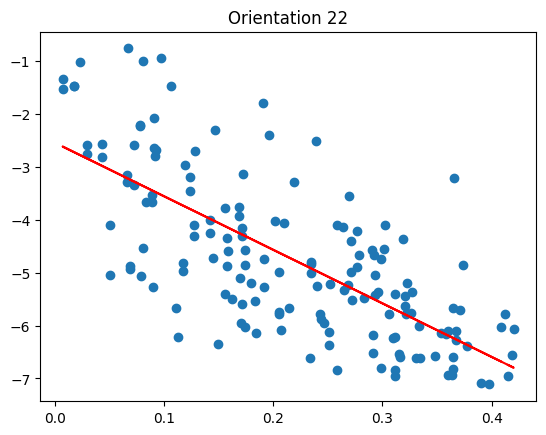

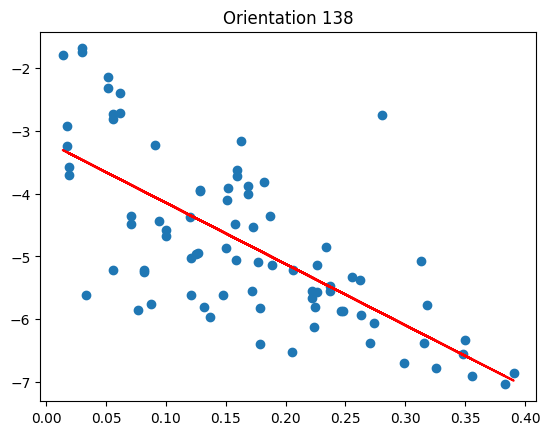

[-8.375988491561198, -9.949169749386739, -10.306655614310488, -10.614672379898566, -10.369028373422772, -10.373484347839696, -10.36018590900768, -9.999211986770458, -9.809190689406963, -9.542310414077262, -10.096757715221202, -10.196626018693435, -9.92822513598921, -9.896193221240662, -10.744300011102895, -10.229012985450174, -10.958836186723023, -10.891992865967193, -11.030641267153063, -10.61490845800151, -10.244983264053797, -10.106836026614237, -10.291106253698068, -9.790453531885401, -9.609547735330448, -8.583523335800539, -9.068118806422472, -8.421945973298214, -7.6945028483903295, -7.547396267021593, -8.084497662361942, -8.178838159985617, -8.44464339386011, -8.690641163821944, -8.50606761972831, -8.589435192047826, -8.46385423008708, -8.996098131443416, -8.891146898982916, -8.632270769040934, -9.113649741910685, -9.217059684751511, -9.372003637859809, -9.482695453158343, -9.75016226370463, -9.9081506454271, -10.26951232690646, -9.940994453770866, -8.802141835826012, -9.02118051

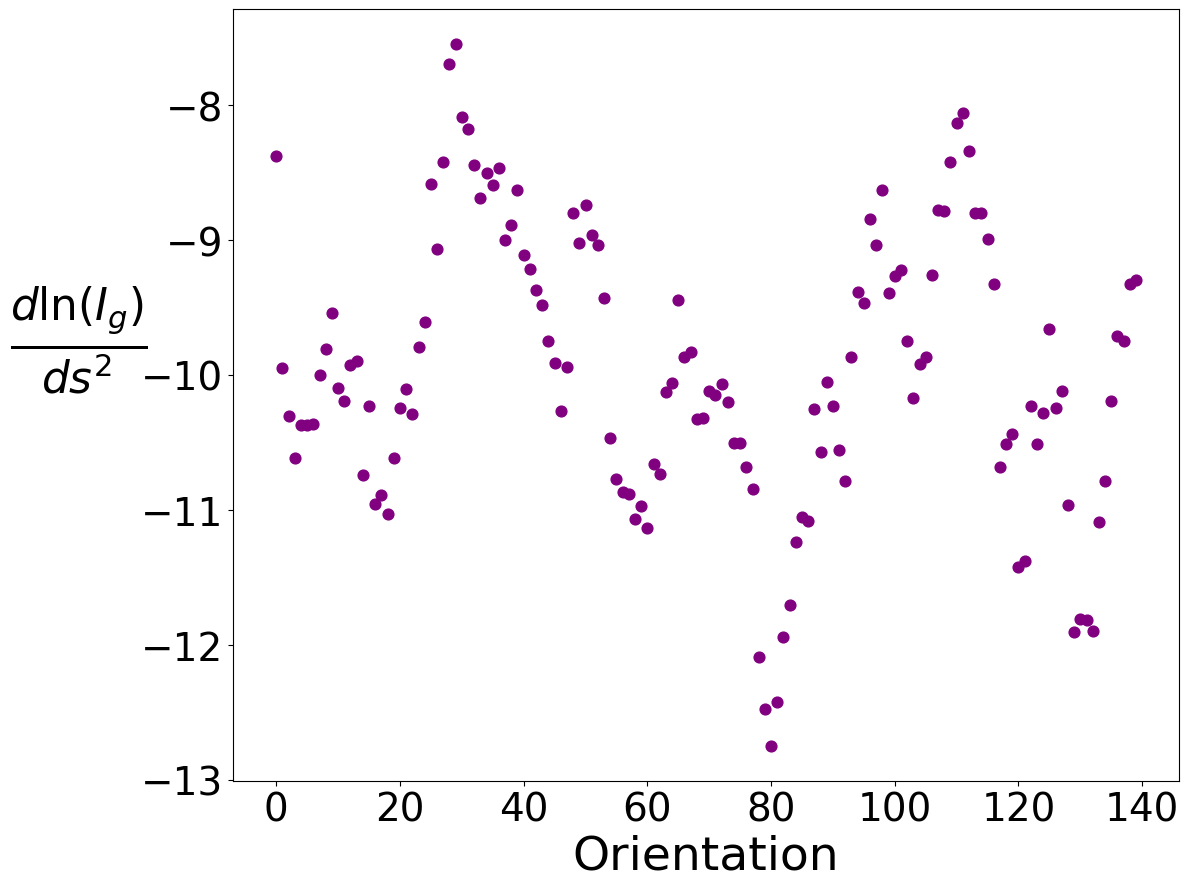

In [11]:
# ------------ Plots slope with just filtering ---------------------------------------


import numpy as np
import matplotlib.pyplot as plt

# --- Extract slopes from previous merged_total data ---
orientations = sorted(merged_total["orientation"].unique())
slopes = []


for ori in orientations:
    df_fit = merged_total[merged_total["orientation"] == ori].copy()
    df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "_refln_intensity_sigma", "G-vector Length"])
    
    # --- Only keep reflections where I > 3σ ---
    df_fit = df_fit[df_fit["_refln_intensity_meas"] > 3 * df_fit["_refln_intensity_sigma"]]
    #df_fit = df_fit[(df_fit["G-vector Length"] / 2.0) ** 2 < 0.6]
    if df_fit.empty:
        continue

    x = (df_fit["G-vector Length"] / 2.0) ** 2
    y = np.log(df_fit["_refln_intensity_meas"])
    #sigma_y = df_fit["_refln_intensity_sigma"] / df_fit["_refln_intensity_meas"]
    #w = 1.0 / (sigma_y ** 2)
    slope, intercept = np.polyfit(x, y, 1)
    slopes.append(slope)
    if ori== 22:
        plt.plot(x,y,'o')
        plt.title('Orientation '+ str(ori))
        plt.plot(x, slope*x + intercept, color='red')
        plt.show()
    if ori== len(orientations)-2:
        plt.plot(x,y,'o')
        plt.title('Orientation '+ str(ori))
        plt.plot(x, slope*x + intercept, color='red')
        plt.show()
    

# --- Define tilt step (user-specified) ---
tilt_step = 1  # degrees per orientation, change as needed

# --- Compute tilt angles ---
tilt_deg = np.arange(0, len(slopes) * tilt_step, tilt_step)[:len(slopes)]

# --- Plot slope vs tilt angle ---
plt.figure(figsize=(12, 9))

plt.scatter(tilt_deg, slopes, color="purple", s=60, marker="o")
print(slopes)
print(np.shape(slopes))
plt.xlabel(r"Orientation", fontsize=34)
plt.ylabel(r"$\frac{d \ln (I_g)}{ds^2}$", fontsize=45, rotation=0, labelpad=45)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)

plt.tight_layout()
plt.savefig(Path(base_dir) / "slope_vs_tilt.png", dpi=300)
plt.show()


[-4.563148891119489, -4.769044600412558, -4.221602879509956, -3.167718402964592, -2.6667710575160637, -3.0781441094039614, -2.9657687302190627, -2.360987914886564, -3.435869527285745, -5.049031742723582, -7.748740754023226, -5.1567372746342, -5.788343907201472, -5.842033479511184, -6.773297924328497, -7.824778097690321, -7.835858887606589, -9.540058605153487, -9.384220955457044, -10.0176263349321, -9.730135248559813, -9.030622914499634, -9.230698424717968, -9.294515748248141, -9.424304985896152, -9.990027483473193, -8.78150281145511, -8.298214245578075, -7.03557315784122, -4.267288231237464, -2.918324268011044, -3.9428083018962434, -5.306838127151272, -4.590719990746099, -5.616701855446636, -5.355614636179596, -4.197959974265902, -3.1010891640426435, -4.9496850771234575, -6.555679097351704, -7.880969499282134, -8.153323096616214, -9.70659561127908, -9.578067189347491, -12.497317058420006, -11.841945516000255, -10.865542001871255, -12.43654414824985, -11.64802524651068, -12.128979595063

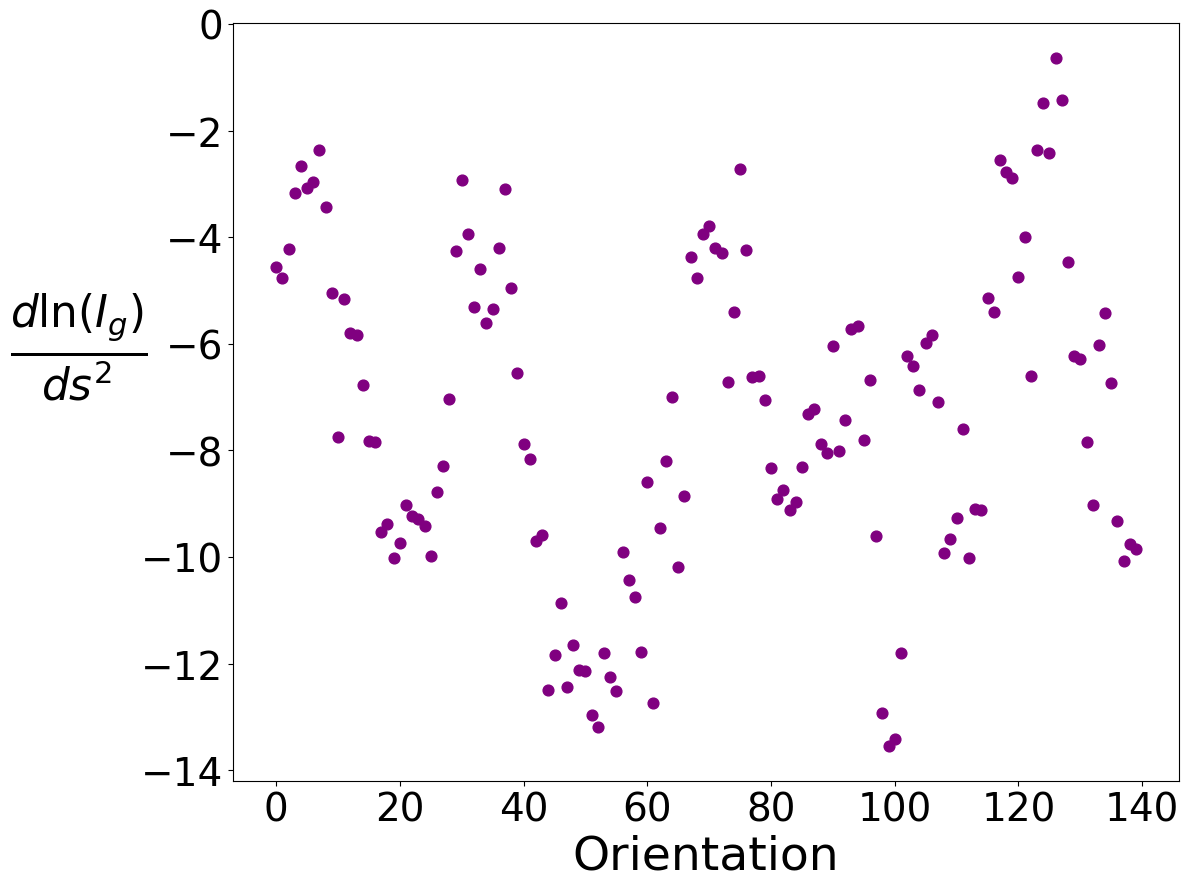

In [15]:
# ------------ Plots slope with only select portion of data ---------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# --- Extract slopes from previous merged_total data ---
orientations = sorted(merged_total["orientation"].unique())
slopes = []
binslopes = []
for ori in orientations:
    df_fit = merged_total[merged_total["orientation"] == ori].copy()
    df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "_refln_intensity_sigma", "G-vector Length"])
    df_fit = df_fit[df_fit["_refln_intensity_meas"] > 3 * df_fit["_refln_intensity_sigma"]]
    x = (df_fit["G-vector Length"] / 2.0) ** 2
    y = np.log(df_fit["_refln_intensity_meas"])


    ########## Most Important part ##########
    mask = (x >= (np.max(x)-np.min(x)) * 0.6) & (x <= (np.max(x)-np.min(x)) * 1)
    #########################################


    x = x[mask]
    y = y[mask]
    slope, intercept = np.polyfit(x, y, 1)
    slopes.append(slope)

# --- Define tilt step (user-specified) ---
tilt_step = 1  # degrees per orientation, change as needed

# --- Compute tilt angles ---
tilt_deg = np.arange(0, len(slopes) * tilt_step, tilt_step)[:len(slopes)]

# --- Plot slope vs tilt angle ---
plt.figure(figsize=(12, 9))

plt.scatter(tilt_deg, slopes, color="purple", s=60, marker="o")
print(slopes)
print(np.shape(slopes))
plt.xlabel(r"Orientation", fontsize=34)
plt.ylabel(r"$\frac{d \ln (I_g)}{ds^2}$", fontsize=45, rotation=0, labelpad=45)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)

plt.tight_layout()
plt.savefig(Path(base_dir) / "slope_vs_tilt.png", dpi=300)
plt.show()

    
    

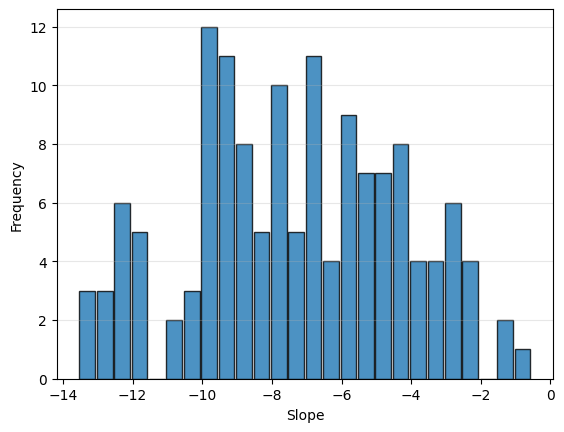

1.0th percentile slope: -13.3281
Lower-tail probability: 0.023523
Slope corresponding to 5% lower-tail probability: -12.2979
Not damaged


In [16]:
# ------------------- Histogram of slopes --------------------------------

hbin_width = 0.5

bins = np.arange(min(slopes), max(slopes) + hbin_width, hbin_width)

counts, bin_edges = np.histogram(slopes, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
plt.bar(
    bin_centers,
    counts,
    width=hbin_width * 0.9,
    edgecolor="black",
    alpha=0.8
)
plt.xlabel("Slope")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

from scipy.stats import norm

slopes = np.asarray(slopes)

# 1. Fit normal distribution to slopes
mu = slopes.mean()
sigma = slopes.std(ddof=1)

# 2. Pick a low quantile instead of absolute minimum
quantile = 0.01  # bottom 1%
worst_slope = np.quantile(slopes, quantile)

# 3. Compute the lower-tail probability
probability = norm.cdf(worst_slope, loc=mu, scale=sigma)

# 4. Decide if damaged (1% threshold)
is_damaged = probability <= 0.025

# 5. Report
print(f"{quantile*100:.1f}th percentile slope: {worst_slope:.4f}")
print(f"Lower-tail probability: {probability:.6f}")

slope_threshold = norm.ppf(0.05, loc=mu, scale=sigma)

print(f"Slope corresponding to 5% lower-tail probability: {slope_threshold:.4f}")
last5_avg = slopes[-3:].mean()

# Decide if damaged
is_damaged = last5_avg <= slope_threshold
print("Damaged" if is_damaged else "Not damaged")

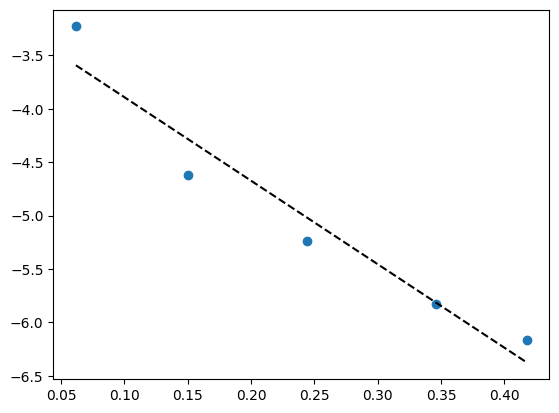

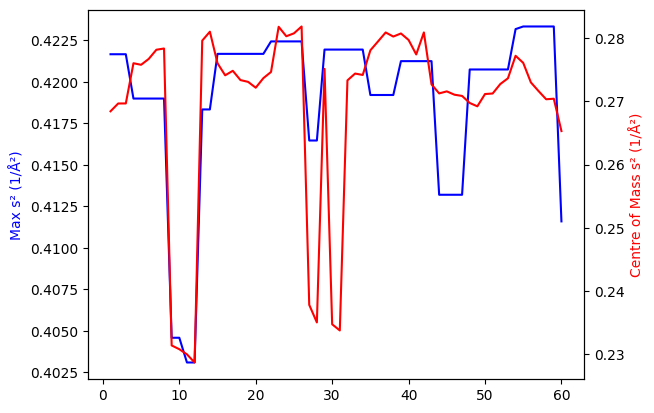

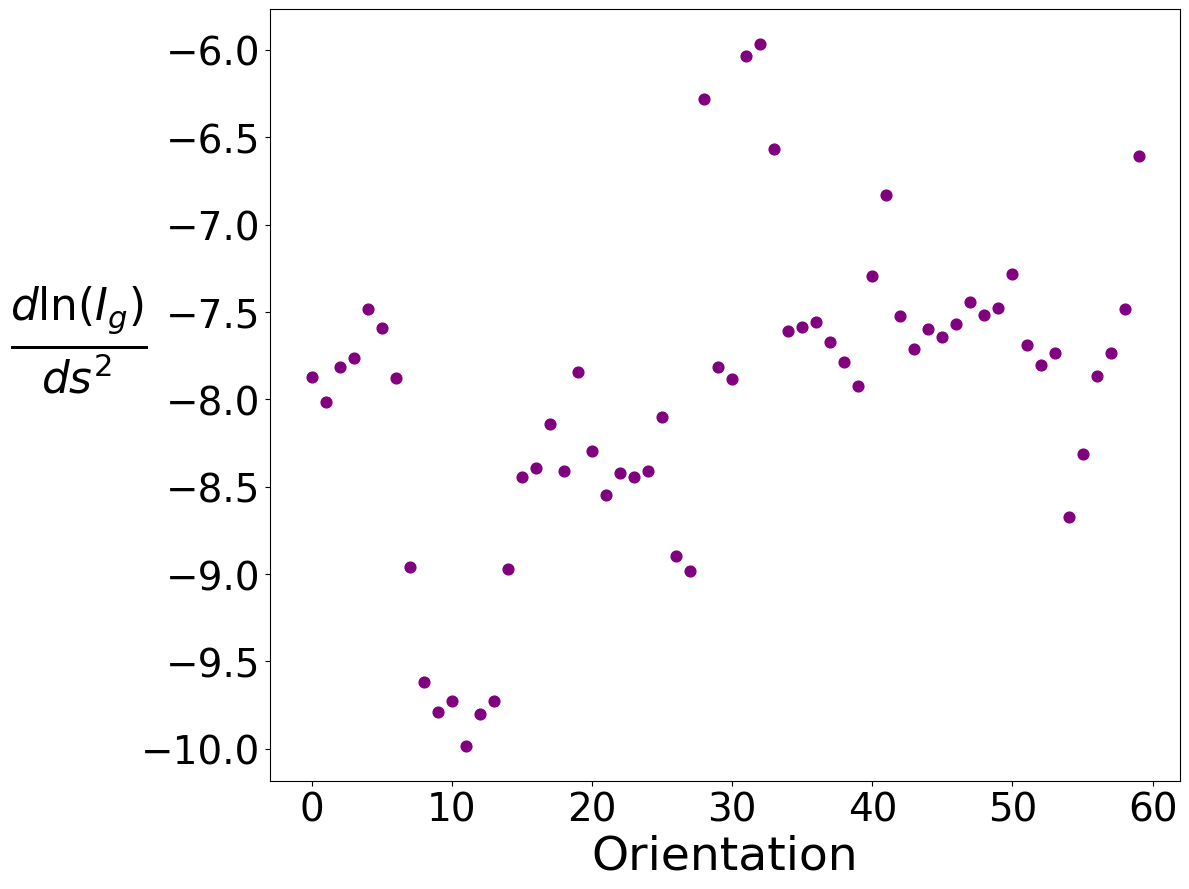

In [20]:
# ------------ Plots slope with binned averaging ---------------------------------------
# ------------ Plots max s² and COM for each ori + Filtered ----------------------------

import numpy as np
import matplotlib.pyplot as plt

# --- Extract slopes from previous merged_total data ---
orientations = sorted(merged_total["orientation"].unique())
s2max = []
s2com = []
slopes = []
binslopes = []
for ori in orientations:
    df_fit = merged_total[merged_total["orientation"] == ori].copy()
    df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "_refln_intensity_sigma", "G-vector Length"])
    df_fit = df_fit[df_fit["_refln_intensity_meas"] > 3 * df_fit["_refln_intensity_sigma"]]
    x = (df_fit["G-vector Length"] / 2.0) ** 2
    y = np.log(df_fit["_refln_intensity_meas"])
    slope, intercept = np.polyfit(x, y, 1)
    slopes.append(slope)
    s2max.append(np.max(x))
    bin_width = 0.1
        

# integer bin index for each x value
    bin_idx = ((x - x.min()) // bin_width).astype(int)

# sum intensity per bin
    bin_sums = np.bincount(bin_idx, weights=y)

# number of reflections per bin
    bin_counts = np.bincount(bin_idx)

# average intensity per bin
    bin_avgy = bin_sums / np.maximum(bin_counts, 1)
    bin_avgx = (np.bincount(bin_idx, weights=x) / np.maximum(bin_counts, 1))
    binslope, binintercept = np.polyfit(bin_avgx, bin_avgy, 1)
    binslopes.append(binslope)
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = intercept + slope * x_fit
    avgx_fit = np.linspace(bin_avgx.min(), bin_avgx.max(), 200)
    avgy_fit = binintercept + binslope * avgx_fit
    
    if ori == 3:
        plt.plot(bin_avgx, bin_avgy, 'o', label='ori 38')
        #plt.plot(x, y, 'x', label='ori 38 data')
        plt.plot(avgx_fit, avgy_fit, color='black', linestyle='--', label=f"orientation {ori} fit")
    if ori == 126:
        plt.plot(bin_avgx, bin_avgy, 'o', label=f"ori {ori}")
        plt.plot(avgx_fit, avgy_fit, color='red', linestyle='--', label=f"orientation {ori} fit")
        #plt.plot(x, y, 'x', label='ori 62 data')
        plt.legend()
        plt.show()
    s2com.append((bin_avgx*bin_avgy).sum()/bin_avgy.sum())

#print(s2com)
fig, ax1 = plt.subplots()
#print(np.arange(1,len(s2com)+1,1))
# First dataset (left y-axis)
ax1.plot(np.arange(1,len(s2com)+1,1), s2max, 'b-')
ax1.set_ylabel("Max s² (1/Å²)", color='b')

# Create second axis sharing the same x
ax2 = ax1.twinx()

# Second dataset (right y-axis)
ax2.plot(np.arange(1,len(s2com)+1,1), s2com, 'r-')
ax2.set_ylabel("Centre of Mass s² (1/Å²)", color='r')
plt.xlabel("Orientation")
plt.show()

# --- Define tilt step (user-specified) ---
tilt_step = 1  # degrees per orientation, change as needed

# --- Compute tilt angles ---
tilt_deg = np.arange(0, len(slopes) * tilt_step, tilt_step)[:len(slopes)]

# --- Plot slope vs tilt angle ---
plt.figure(figsize=(12, 9))

plt.scatter(tilt_deg, binslopes, color="purple", s=60, marker="o")
#print(binslopes)
#print(np.shape(slopes))
plt.xlabel(r"Orientation", fontsize=34)
plt.ylabel(r"$\frac{d \ln (I_g)}{ds^2}$", fontsize=45, rotation=0, labelpad=45)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)

plt.tight_layout()
plt.savefig(Path(base_dir) / "slope_vs_tiltbinned.png", dpi=300)
plt.show()


[-7.9755785977132145, -7.42156973754846, -7.619381252420891, -7.327601169316627, -7.5005258661509595, -7.516989990895214, -7.3790756032644635, -7.127708220037971, -6.957586190317824, -7.657834109601765, -7.949602143616987, -8.146901737730204, -8.263423834534018, -7.7666877824719736, -7.906102874434694, -7.6560841594266265, -8.201906424767925, -8.134725393469886, -7.903792460414093, -8.075186630570077, -8.263677002603627, -8.44970643328528, -8.575977605568378, -8.586885149123177, -8.793813439480074, -8.272814114701534, -8.640312536113187, -8.836835386075904, -8.725688166230961, -8.279352783220688, -8.368967855092395, -8.39240510476279, -8.557559710413482, -8.282178275220547, -8.59059114842669, -8.474698773143206, -9.208959702395584, -10.256840013429333, -10.399962029108773, -9.885312357165809, -9.634933904527207, -9.245403931276998, -8.865883621184068, -8.662038653206295, -8.575575822829133, -8.998634680362095, -8.931474816618772, -9.071399556392938, -9.402268266683823, -8.7454691492359

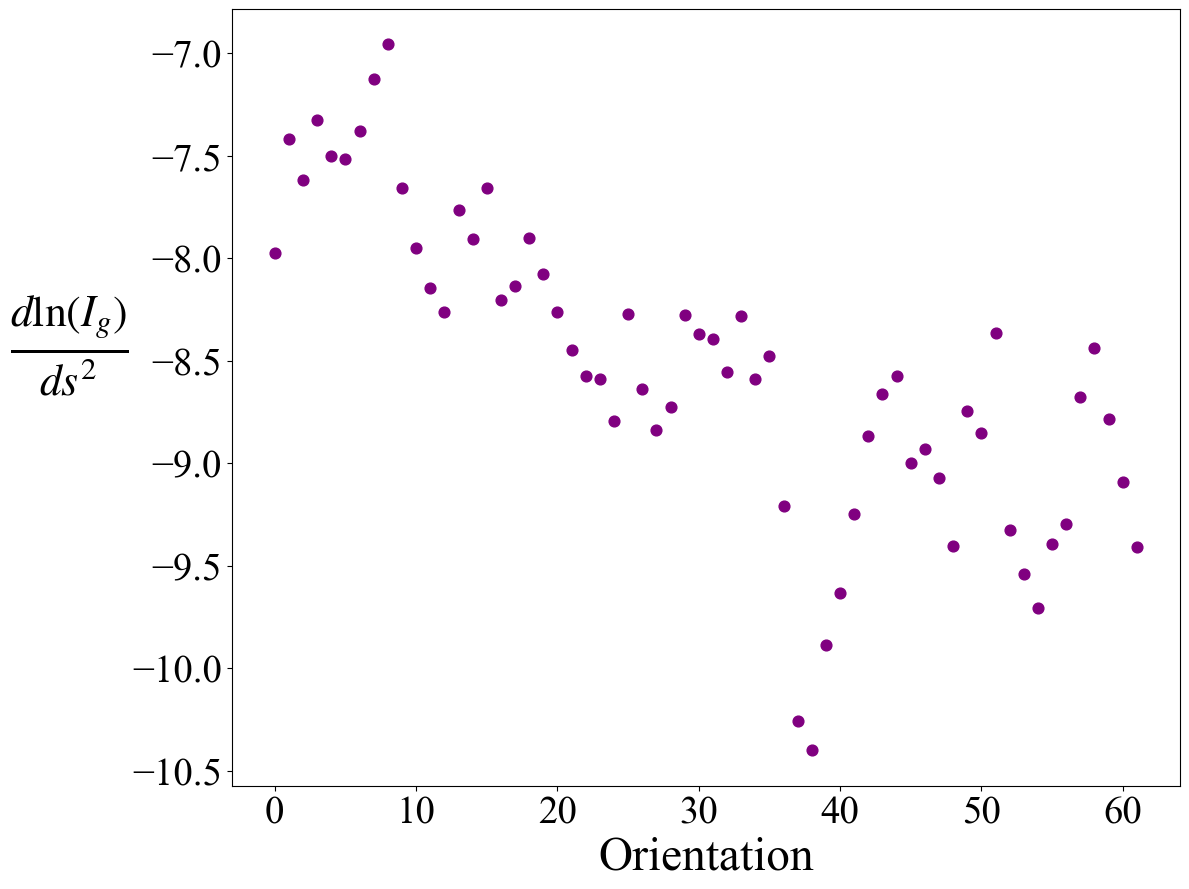

In [ ]:
# ------------ Plots slope with max s² imposed ---------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# --- Extract slopes from previous merged_total data ---
orientations = sorted(merged_total["orientation"].unique())
slopes = []
binslopes = []
for ori in orientations:
    df_fit = merged_total[merged_total["orientation"] == ori].copy()
    df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "_refln_intensity_sigma", "G-vector Length"])
    df_fit = df_fit[df_fit["_refln_intensity_meas"] > 0 * df_fit["_refln_intensity_sigma"]]
    x = (df_fit["G-vector Length"] / 2.0) ** 2
    y = np.log(df_fit["_refln_intensity_meas"])
    mask = x <= np.min(s2max)
    x = x[mask]
    y = y[mask]
    slope, intercept = np.polyfit(x, y, 1)
    slopes.append(slope)

# --- Define tilt step (user-specified) ---
tilt_step = 1  # degrees per orientation, change as needed

# --- Compute tilt angles ---
tilt_deg = np.arange(0, len(slopes) * tilt_step, tilt_step)[:len(slopes)]

# --- Plot slope vs tilt angle ---
plt.figure(figsize=(12, 9))

plt.scatter(tilt_deg, slopes, color="purple", s=60, marker="o")
print(slopes)
print(np.shape(slopes))
plt.xlabel(r"Orientation", fontsize=34)
plt.ylabel(r"$\frac{d \ln (I_g)}{ds^2}$", fontsize=45, rotation=0, labelpad=45)

plt.xticks(fontsize=28)
plt.yticks(fontsize=28)

plt.tight_layout()
plt.savefig(Path(base_dir) / "slope_vs_tilt.png", dpi=300)
plt.show()

    
    

-3.7514287906005377
-8.108938087952769


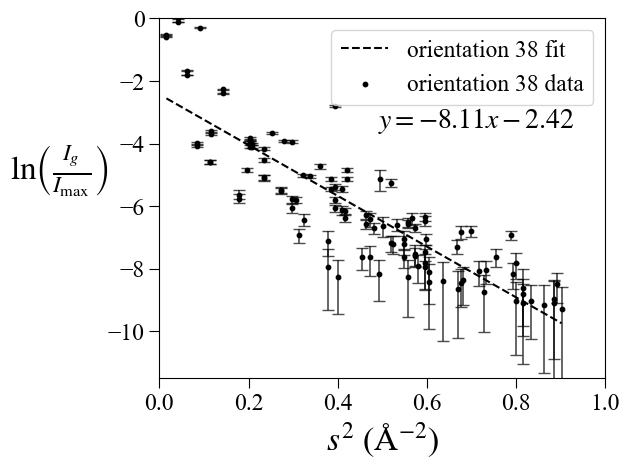

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- Loop over orientations in merged_total ---
orientations = sorted(merged_total["orientation"].unique())



# ------------------------------------------
# ORIENTATION 3
# ------------------------------------------
for ori in orientations:
    if ori == 38:
        df_fit = merged_total[merged_total["orientation"] == ori].copy()
        df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "G-vector Length"])
        df_fit = df_fit[(df_fit["_refln_intensity_meas"] > 0) & (df_fit["_refln_intensity_meas"] > 1*df_fit["_refln_intensity_sigma"])]
        #df_fit = df_fit[(df_fit["G-vector Length"] / 2.0) ** 2 < 0.6]
        if df_fit.empty:
            continue

        x = (df_fit["G-vector Length"] / 2.0) ** 2
        y = np.log(df_fit["_refln_intensity_meas"])

        yerrmax = np.log(df_fit["_refln_intensity_sigma"] / df_fit["_refln_intensity_meas"] + 1)
        yerrmin = np.log(df_fit["_refln_intensity_meas"] / (df_fit["_refln_intensity_meas"] - df_fit["_refln_intensity_sigma"]))
        w=1/(yerrmax**2)
        slope, intercept = np.polyfit(x, y, 1, w=w)
        print(slope)
        x_fit = np.linspace(x.min(), x.max(), 200)
        y_fit = intercept + slope * x_fit
        #plt.plot(x_fit, y_fit, color='C0', linestyle='--', label=f"orientation {ori} weighted fit")
        slope, intercept = np.polyfit(x, y, 1 )
        print(slope)
        x_fit = np.linspace(x.min(), x.max(), 200)
        y_fit = intercept + slope * x_fit
        plt.rcParams['mathtext.fontset'] = 'stix'
        plt.rcParams['font.family'] = 'Times New Roman'
   
        plt.tick_params(axis='both', which='major', labelsize=17, length=7) 
        plt.plot(x_fit, y_fit, color='black', linestyle='--', label=f"orientation {ori} fit")
        plt.scatter(x, y, s=10, label=f"orientation {ori} data", linewidth=1, marker='o', color='black')
        plt.errorbar(x, y, yerr=[yerrmin, yerrmax],
                     ecolor='black', capsize=4, linestyle='none', fmt='none', elinewidth=1.2, alpha=0.7)

        #plt.set_title("Orientation 3")
        plt.legend(fontsize=17)



        plt.xlabel(r"$s^2$ (Å$^{-2}$)", fontsize=24, fontfamily="Times New Roman")
        equation = f"$y = {slope:.2f}x  {intercept:.2f}$"

# Add to plot (x=position along x-axis, y=position along y-axis)
        plt.text(x=0.49, y=-3.5, s=equation, fontsize=20, color='black', fontfamily="Times New Roman")
        ylabel = plt.ylabel(r"$\ln\!\left(\frac{I_g}{I_{\mathrm{max}}}\right)$", fontsize=24, rotation=0,labelpad=35, fontfamily="Times New Roman")
        #ylabel.set_verticalalignment('bottom')    # keep it aligned with the top of the axis
        #ylabel.set_horizontalalignment('right')   # adjust horizontal alignment
        #ylabel.set_position((0.8, 0.854))           # (x, y) relative to axis; y=1 is top, x>1 moves it right
        plt.ylim(-11.5,0)
        plt.xlim(0,1)
        #plt.set_ylim(y.min() - 0.90*(y.max()-y.min()), y.max() + 0.05*(y.max()-y.min()))

plt.tight_layout()
plt.savefig(Path(base_dir) /"orientation", dpi=500)
plt.show()



In [254]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import tkinter as tk
import pandas as pd
from pathlib import Path

# ------------------------------------------------------
#  YOUR DATA (must exist): merged_total
# ------------------------------------------------------
# merged_total = pd.read_csv("your_file.csv")  # example

# -----------------------------
# SAVE LOCATION (using pathlib)
# -----------------------------
save_path = Path(r"C:/Users/Sauron/Documents/bc626/checkpoint_preprocess/data/damage/urea")
full_path = save_path / "saved_plot.png"

# ------------------------------------------------------
# FUNCTIONS TO PLOT
# ------------------------------------------------------
def plot_two(fig, merged_total):
    fig.clear()
    orientations = sorted(merged_total["orientation"].unique())
    ax1, ax2 = fig.subplots(1, 2)

    for ori in orientations:
        if ori == 3:
            df_fit = merged_total[merged_total["orientation"] == ori].copy()
            df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "G-vector Length"])
            df_fit = df_fit[(df_fit["_refln_intensity_meas"] > 0) &
                            (df_fit["_refln_intensity_meas"] > 0*df_fit["_refln_intensity_sigma"])]
            if df_fit.empty:
                continue
            x = (df_fit["G-vector Length"] / 2.0) ** 2
            y = np.log(df_fit["_refln_intensity_meas"])
            yerrmax = np.log(df_fit["_refln_intensity_sigma"] / df_fit["_refln_intensity_meas"] + 1)
            yerrmin = np.log(df_fit["_refln_intensity_meas"] / (df_fit["_refln_intensity_meas"] - df_fit["_refln_intensity_sigma"]))
            w = 1 / (yerrmax ** 2)
            slope, intercept = np.polyfit(x, y, 1, w=w)
            x_fit = np.linspace(x.min(), x.max(), 200)
            ax1.plot(x_fit, intercept + slope * x_fit, color='C0', linestyle='--', label=f"orientation {ori} weighted fit")
            slope, intercept = np.polyfit(x, y, 1)
            ax1.plot(x_fit, intercept + slope * x_fit, color='C1', linestyle='--', label=f"orientation {ori} fit")
            ax1.scatter(x, y, s=25, color='C0')
            ax1.errorbar(x, y, yerr=[yerrmin, yerrmax], ecolor='C0', capsize=3, linestyle='none', fmt='none')
            ax1.set_title("Orientation 3")
            ax1.legend(fontsize=20, loc='lower right')
            ax1.tick_params(labelsize=28)
            ax1.set_ylim(y.min() - 0.90*(y.max()-y.min()), y.max() + 0.05*(y.max()-y.min()))

        if ori == 50:
            df_fit = merged_total[merged_total["orientation"] == ori].copy()
            df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "G-vector Length"])
            df_fit = df_fit[(df_fit["_refln_intensity_meas"] > 0) &
                            (df_fit["_refln_intensity_meas"] > 0*df_fit["_refln_intensity_sigma"])]
            if df_fit.empty:
                continue
            x = (df_fit["G-vector Length"] / 2.0) ** 2
            y = np.log(df_fit["_refln_intensity_meas"])
            yerrmax = np.log(df_fit["_refln_intensity_sigma"] / df_fit["_refln_intensity_meas"] + 1)
            yerrmin = np.log(df_fit["_refln_intensity_meas"] / (df_fit["_refln_intensity_meas"] - df_fit["_refln_intensity_sigma"]))
            w = 1 / (yerrmax ** 2)
            slope, intercept = np.polyfit(x, y, 1, w=w)
            x_fit = np.linspace(x.min(), x.max(), 200)
            ax2.plot(x_fit, intercept + slope * x_fit, color='C2', linestyle='--', label=f"orientation {ori} weighted fit")
            slope, intercept = np.polyfit(x, y, 1)
            ax2.plot(x_fit, intercept + slope * x_fit, color='C3', linestyle='--', label=f"orientation {ori} fit")
            ax2.scatter(x, y, s=25, color='C2')
            ax2.errorbar(x, y, yerr=[yerrmin, yerrmax], ecolor='C2', capsize=3, linestyle='none', fmt='none')
            ax2.set_title("Orientation 50")
            ax2.legend(fontsize=20, loc='lower right')
            ax2.tick_params(labelsize=28)
            ax2.set_ylim(y.min() - 0.90*(y.max()-y.min()), y.max() + 0.05*(y.max()-y.min()))

    fig.supxlabel(r"$s^2$  ($\mathrm{\AA}^{-2}$)", fontsize=34)
    fig.supylabel(r"$\ln(I_g)$", fontsize=45)
    fig.tight_layout()


def plot_one(fig, merged_total):
    fig.clear()
    ax = fig.add_subplot(111)
    orientations = sorted(merged_total["orientation"].unique())

    color_map = {3: ('C0', 'C1'), 50: ('C2', 'C3')}  # (weighted_fit_color, fit_color)

    for ori in [3, 50]:
        if ori not in orientations:
            continue
        df_fit = merged_total[merged_total["orientation"] == ori].copy()
        df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "G-vector Length"])
        df_fit = df_fit[(df_fit["_refln_intensity_meas"] > 0) &
                        (df_fit["_refln_intensity_meas"] > 0*df_fit["_refln_intensity_sigma"])]
        if df_fit.empty:
            continue

        x = (df_fit["G-vector Length"] / 2.0) ** 2
        y = np.log(df_fit["_refln_intensity_meas"])
        yerrmax = np.log(df_fit["_refln_intensity_sigma"] / df_fit["_refln_intensity_meas"] + 1)
        yerrmin = np.log(df_fit["_refln_intensity_meas"] / (df_fit["_refln_intensity_meas"] - df_fit["_refln_intensity_sigma"]))
        w = 1 / (yerrmax ** 2)

        slope, intercept = np.polyfit(x, y, 1, w=w)
        x_fit = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_fit, intercept + slope * x_fit, linestyle='--', color=color_map[ori][0],
                label=f"{ori} weighted fit")

        slope, intercept = np.polyfit(x, y, 1)
        ax.plot(x_fit, intercept + slope * x_fit, linestyle='--', color=color_map[ori][1],
                label=f"{ori} fit")

        ax.scatter(x, y, s=25, color=color_map[ori][0])
        ax.errorbar(x, y, yerr=[yerrmin, yerrmax], ecolor=color_map[ori][0],
                    capsize=3, linestyle='none', fmt='none')

    ax.set_title("Orientations 3 & 50 (combined)")
    ax.legend(fontsize=12)
    ax.tick_params(labelsize=14)
    fig.supxlabel(r"$s^2$  ($\mathrm{\AA}^{-2}$)", fontsize=24)
    fig.supylabel(r"$\ln(I_g)$", fontsize=30)
    fig.tight_layout()


# ------------------------------------------------------
#  TKINTER GUI + TOGGLE + SAVE
# ------------------------------------------------------
root = tk.Tk()
root.title("Plot Toggle")

fig = plt.Figure(figsize=(14, 6))
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.get_tk_widget().pack(fill="both", expand=True)

two_plots = True   # start in 2-subplot mode

def toggle():
    global two_plots
    two_plots = not two_plots
    if two_plots:
        plot_two(fig, merged_total)
        button.config(text="Switch to 1 Plot")
    else:
        plot_one(fig, merged_total)
        button.config(text="Switch to 2 Plots")
    canvas.draw()

# --- Save button ---
def save_current():
    save_path.mkdir(parents=True, exist_ok=True)  # ensure folder exists
    print(f"Saving to: {full_path}")              # debug print
    fig.savefig(full_path, dpi=300)
    print(f"Plot saved to {full_path}")

button = tk.Button(root, text="Switch to 1 Plot", command=toggle, font=("Arial", 16))
button.pack()

save_button = tk.Button(root, text="Save Plot", command=save_current, font=("Arial", 16))
save_button.pack()

# initial draw
plot_two(fig, merged_total)
canvas.draw()

root.mainloop()


c:\Users\Sauron\Documents\bc626\checkpoint_preprocess\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Sauron\Documents\bc626\checkpoint_preprocess\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Sauron\Documents\bc626\checkpoint_preprocess\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Sauron\Documents\bc626\checkpoint_preprocess\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Orientation 2: correction applied = -0.361517
Orientation 3: correction applied = -0.361517
Orientation 4: correction applied = -0.361517
Orientation 5: correction applied = -0.361517
Orientation 6: correction applied = -0.361517
Orientation 7: correction applied = -0.361517
Orientation 8: correction applied = -0.361517
Orientation 9: correction applied = -0.361517
Orientation 10: correction applied = -0.361517
Orientation 11: correction applied = -0.361517
Orientation 12: correction applied = -0.622098
Orientation 13: correction applied = -0.648156
Orientation 14: correction applied = -0.674214
Orientation 15: correction applied = -0.700272
Orientation 16: correction applied = -0.726330
Orientation 17: correction applied = -0.752388
Orientation 18: correction applied = -0.778446
Orientation 19: correction applied = -0.804504
Orientation 20: correction applied = -0.830562
Orientation 21: correction applied = -0.856620
Orientation 22: correction applied = -0.882678
Orientation 23: corre

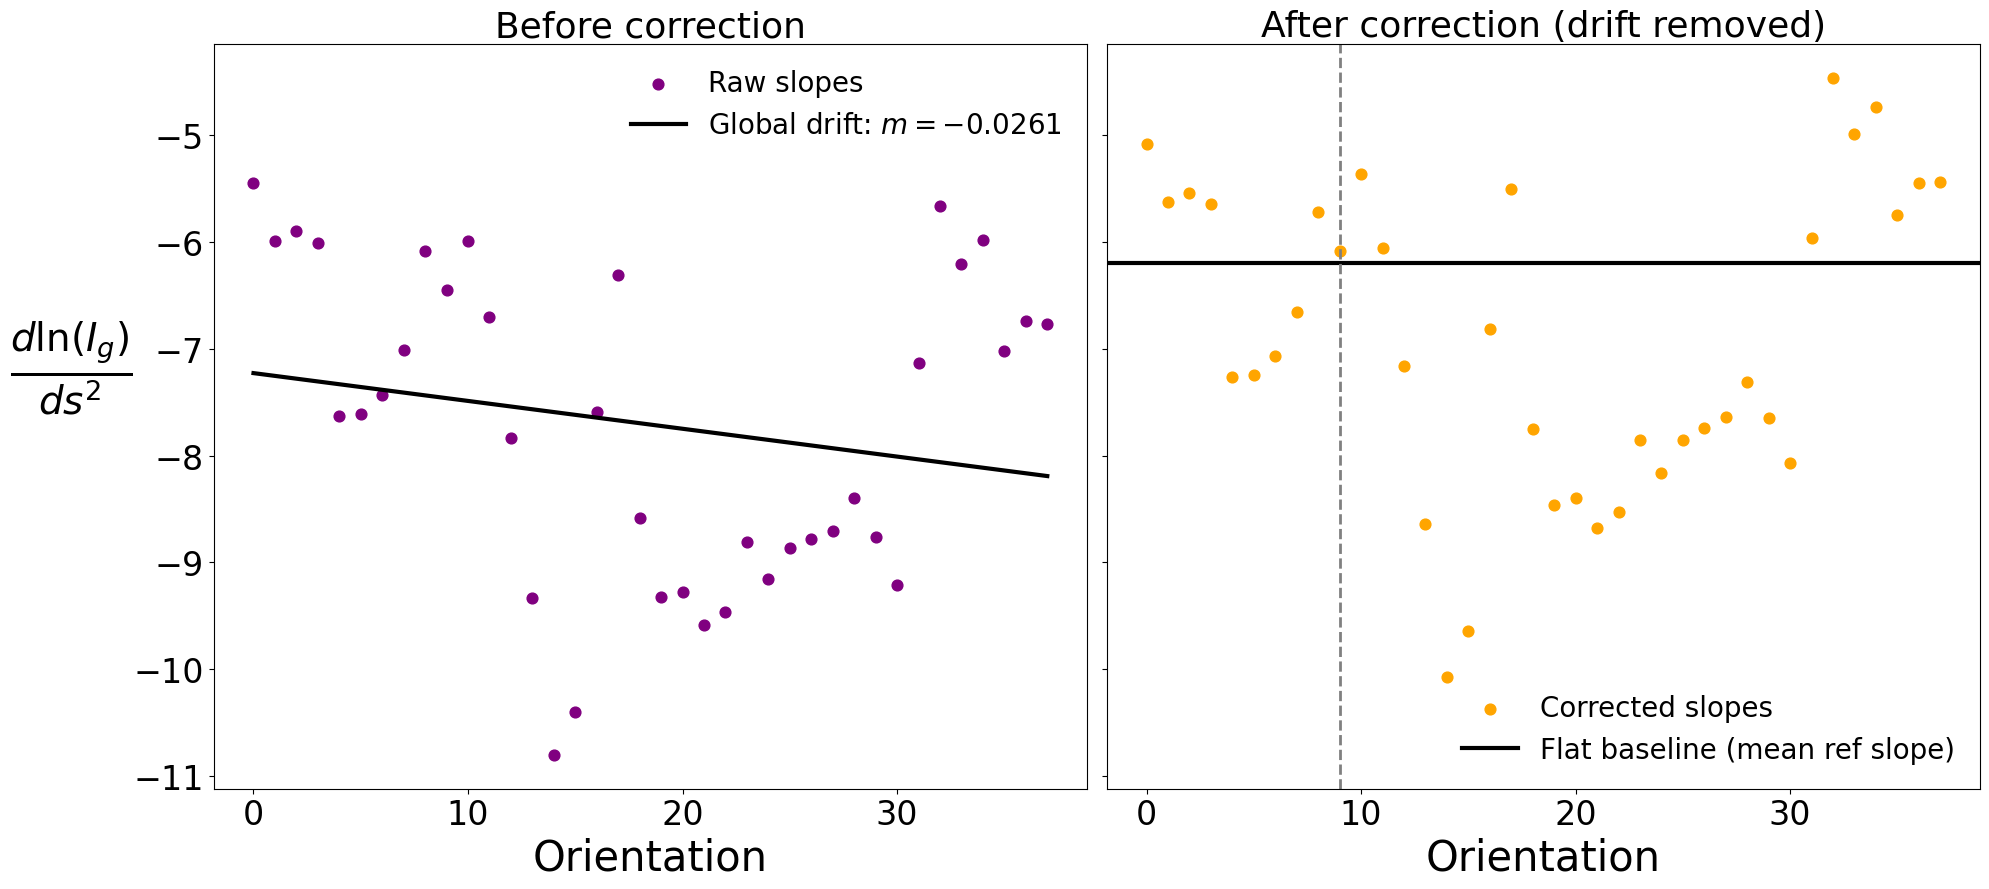

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- Extract slopes from merged_total ---
orientations = sorted(merged_total["orientation"].unique())
slopes = []

for ori in orientations:
    df_fit = merged_total[merged_total["orientation"] == ori].copy()
    df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "G-vector Length"])
    df_fit = df_fit[df_fit["_refln_intensity_meas"] > 0]
    if df_fit.empty:
        continue
    x = (df_fit["G-vector Length"] / 2.0) ** 2
    y = np.log(df_fit["_refln_intensity_meas"])
    slope, intercept = np.polyfit(x, y, 1)
    slopes.append(slope)

# --- Define tilt step ---
tilt_step = 1
tilt_deg = np.arange(0, len(slopes) * tilt_step, tilt_step)[:len(slopes)]

# --- Reference: mean slope of first 10 orientations ---
mean_ref_slope = np.mean(slopes[:5])

# --- Fit global drift across all orientations ---
fit_coeffs = np.polyfit(tilt_deg, slopes, 1)
fit_line = np.polyval(fit_coeffs, tilt_deg)

# --- Correction: remove only the linear drift component ---
# Keep the first 10 fixed; apply small per-orientation correction after
corrected_slopes = np.copy(slopes)
drift_to_remove = fit_line - fit_line[0]  # relative drift
corrected_slopes[10:] = slopes[10:] - drift_to_remove[10:]

# --- Shift baseline to match mean_ref_slope ---
delta_mean = np.mean(corrected_slopes[:10]) - mean_ref_slope
corrected_slopes -= delta_mean

# --- Compute correction factors for logging ---
correction_factors = slopes - corrected_slopes

# --- Print correction applied per orientation ---
for ori, corr in zip(orientations, correction_factors):
    print(f"Orientation {ori}: correction applied = {corr:.6f}")

# --- Plot before and after correction ---
fig, axes = plt.subplots(1, 2, figsize=(20, 9), sharey=True)

# Before
axes[0].scatter(tilt_deg, slopes, color="purple", s=60, label="Raw slopes")
axes[0].plot(tilt_deg, fit_line, color="black", linewidth=3.0,
             label=fr"Global drift: $m={fit_coeffs[0]:.4f}$")
axes[0].set_title("Before correction", fontsize=26)
axes[0].set_xlabel("Orientation", fontsize=30)
axes[0].set_ylabel(r"$\frac{d \ln (I_g)}{ds^2}$", fontsize=40, rotation=0, labelpad=45)
axes[0].tick_params(axis='both', labelsize=24)
axes[0].legend(frameon=False, fontsize=20)

# After
axes[1].scatter(tilt_deg, corrected_slopes, color="orange", s=60, label="Corrected slopes")
axes[1].axhline(mean_ref_slope, color="black", linewidth=3.0, label="Flat baseline (mean ref slope)")
axes[1].axvline(9, color="gray", linestyle="--", linewidth=2)
axes[1].set_title("After correction (drift removed)", fontsize=26)
axes[1].set_xlabel("Orientation", fontsize=30)
axes[1].tick_params(axis='both', labelsize=24)
axes[1].legend(frameon=False, fontsize=20)

plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------
# 5. Count reflections with I > 3*sigma per orientation
# ------------------------------------------------------
orientations = sorted(merged_total["orientation"].unique())

total_reflections = 0
total_above_3sigma = 0

print("\nReflections with I > 3σ per orientation:\n")
for ori in orientations:
    df_ori = merged_total[merged_total["orientation"] == ori]
    count = (df_ori["_refln_intensity_meas"] > 3 * df_ori["_refln_intensity_sigma"]).sum()
    total = len(df_ori)

    total_reflections += total
    total_above_3sigma += count

    print(f"Orientation {ori:3d}: {count:5d} / {total:5d} reflections ({count/total*100:5.1f}%)")

print("\n------------------------------------------------------")
print(f"Total: {total_above_3sigma:,d} / {total_reflections:,d} reflections "
      f"({total_above_3sigma/total_reflections*100:5.1f}%) above 3σ overall")
print("------------------------------------------------------")
# ------------------------------------------------------
# 6. Count unique reflections with I > 3σ across all orientations
# ------------------------------------------------------
mask_3sigma = merged_total["_refln_intensity_meas"] > 3 * merged_total["_refln_intensity_sigma"]

unique_all = merged_total["hkl"].drop_duplicates()
unique_above_3sigma = merged_total.loc[mask_3sigma, "hkl"].drop_duplicates()

print("\n------------------------------------------------------")
print(f"Unique reflections total: {len(unique_all):,d}")
print(f"Unique reflections with I > 3σ: {len(unique_above_3sigma):,d}")
print(f"Fraction above 3σ: {len(unique_above_3sigma) / len(unique_all) * 100:5.1f}%")
print("------------------------------------------------------")




Reflections with I > 3σ per orientation:

Orientation   2:    87 /   122 reflections ( 71.3%)
Orientation   3:    97 /   123 reflections ( 78.9%)
Orientation   4:   101 /   125 reflections ( 80.8%)
Orientation   5:   109 /   126 reflections ( 86.5%)
Orientation   6:   108 /   125 reflections ( 86.4%)
Orientation   7:   105 /   123 reflections ( 85.4%)
Orientation   8:    99 /   125 reflections ( 79.2%)
Orientation   9:    95 /   133 reflections ( 71.4%)
Orientation  10:    86 /   130 reflections ( 66.2%)
Orientation  11:    67 /   112 reflections ( 59.8%)
Orientation  12:    72 /   120 reflections ( 60.0%)
Orientation  13:    69 /   118 reflections ( 58.5%)
Orientation  14:    68 /   117 reflections ( 58.1%)
Orientation  15:    75 /   120 reflections ( 62.5%)
Orientation  16:    86 /   121 reflections ( 71.1%)
Orientation  17:    92 /   128 reflections ( 71.9%)
Orientation  18:   101 /   134 reflections ( 75.4%)
Orientation  19:   104 /   137 reflections ( 75.9%)
Orientation  20:   10

Orientation 3: best split s² = 0.190, χ² improvement = 22.19%
Orientation 45: best split s² = 0.277, χ² improvement = 24.34%
Orientation 75: best split s² = 0.356, χ² improvement = 60.26%


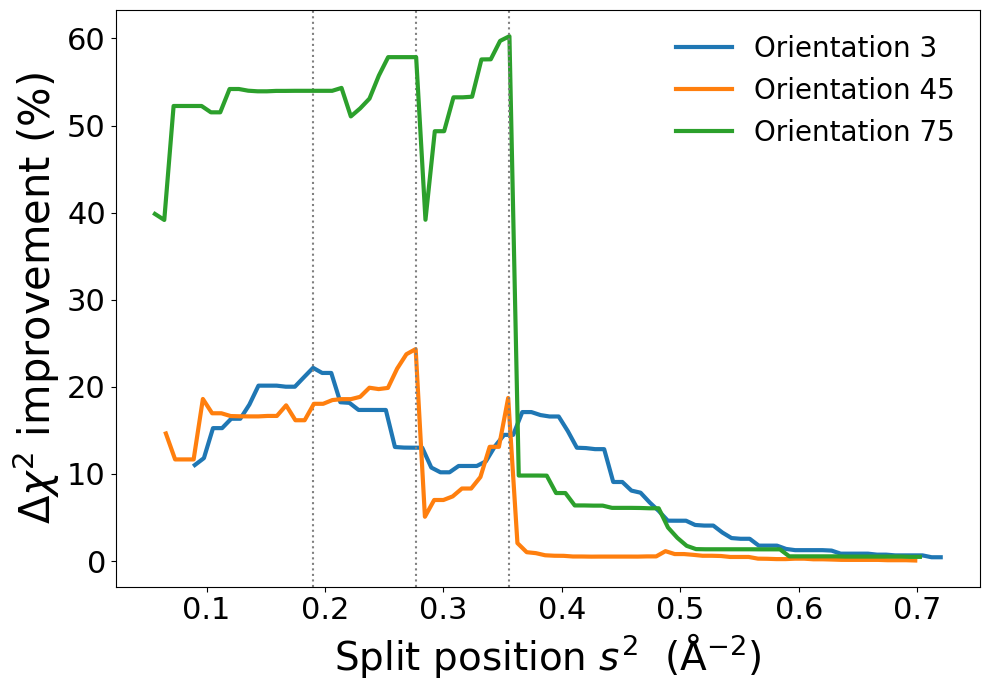

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# --- Loop over orientations ---
for ori in [3, 45,75]:
    df_fit = merged_total[merged_total["orientation"] == ori].copy()
    df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "_refln_intensity_sigma", "G-vector Length"])
    df_fit = df_fit[df_fit["_refln_intensity_meas"] > 0.5 * df_fit["_refln_intensity_sigma"]]
    if df_fit.empty:
        continue

    # --- variables ---
    x = (df_fit["G-vector Length"] / 2.0) ** 2
    y = np.log(df_fit["_refln_intensity_meas"])
    sigma_y = df_fit["_refln_intensity_sigma"] / df_fit["_refln_intensity_meas"]
    w = 1.0 / (sigma_y ** 2)

    # --- sort by x ---
    order = np.argsort(x)
    x, y, sigma_y, w = x.iloc[order], y.iloc[order], sigma_y.iloc[order], w.iloc[order]

    # --- weighted fit function ---
    def weighted_fit(x, y, w):
        W = np.sum(w)
        Wx = np.sum(w * x)
        Wy = np.sum(w * y)
        Wxx = np.sum(w * x * x)
        Wxy = np.sum(w * x * y)
        denom = W * Wxx - Wx ** 2
        slope = (W * Wxy - Wx * Wy) / denom
        intercept = (Wxx * Wy - Wx * Wxy) / denom
        y_fit = intercept + slope * x
        chi2 = np.sum(w * (y - y_fit) ** 2)
        return slope, intercept, chi2

    # --- single-slope baseline ---
    slope_single, intercept_single, chi2_single = weighted_fit(x, y, w)

    # --- generate 100 split candidates evenly across the full s² range ---
    split_values = np.linspace(x.min() + 0.05 * (x.max() - x.min()),
                               x.max() - 0.05 * (x.max() - x.min()), 100)

    improvements = []
    for s_split in split_values:
        mask_left = x <= s_split
        mask_right = x > s_split

        if mask_left.sum() < 5 or mask_right.sum() < 5:
            improvements.append(np.nan)
            continue

        slope1, intercept1, chi2_1 = weighted_fit(x[mask_left], y[mask_left], w[mask_left])
        slope2, intercept2, chi2_2 = weighted_fit(x[mask_right], y[mask_right], w[mask_right])
        total_chi2 = chi2_1 + chi2_2
        delta_chi2 = chi2_single - total_chi2
        improvements.append(delta_chi2)

    improvements = np.array(improvements)
    improvements_pct = 100 * improvements / chi2_single

    # --- plot improvement vs split position ---
    plt.plot(split_values, improvements_pct, linewidth=3.0, label=f"Orientation {ori}")

    best_idx = np.nanargmax(improvements_pct)
    best_split = split_values[best_idx]
    plt.axvline(best_split, color='gray', linestyle=':', linewidth=1.5)
    print(f"Orientation {ori}: best split s² = {best_split:.3f}, χ² improvement = {improvements_pct[best_idx]:.2f}%")

plt.xlabel(r"Split position $s^2$  ($\mathrm{\AA}^{-2}$)", fontsize=28)
plt.ylabel(r"$\Delta \chi^2$ improvement (%)", fontsize=30)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(fontsize=20, loc="best", frameon=False)
plt.tight_layout()
plt.show()


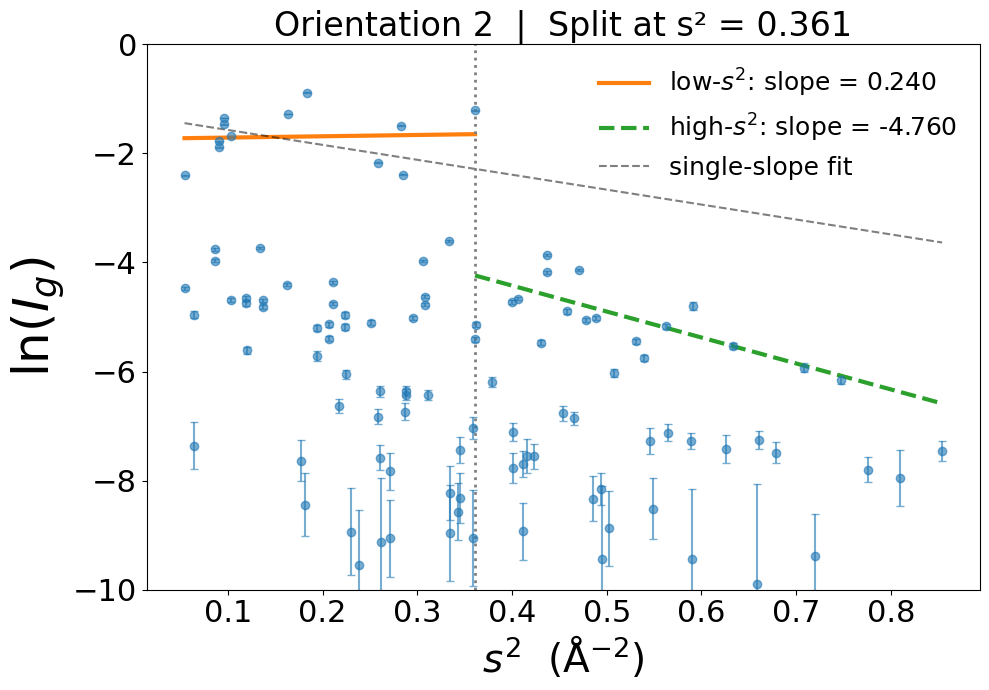

Orientation 2:
  Best split at s² = 0.361
  χ² single-slope = 406576.923
  χ² two-slope    = 305547.738
  Δχ² improvement = 101029.186 (24.8%)
  Slopes = (0.240, -4.760)



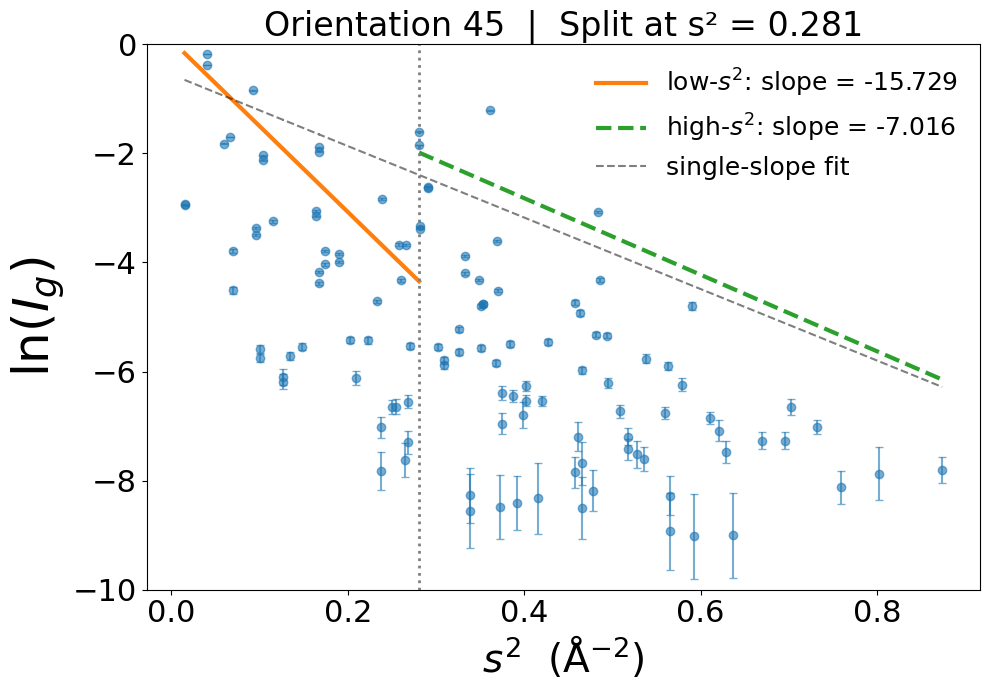

Orientation 45:
  Best split at s² = 0.281
  χ² single-slope = 575525.306
  χ² two-slope    = 435468.916
  Δχ² improvement = 140056.390 (24.3%)
  Slopes = (-15.729, -7.016)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Loop over selected orientations ---
for ori in [2,45]:
    df_fit = merged_total[merged_total["orientation"] == ori].copy()
    df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "_refln_intensity_sigma", "G-vector Length"])
    df_fit = df_fit[df_fit["_refln_intensity_meas"] > 0.5 * df_fit["_refln_intensity_sigma"]]
    if df_fit.empty:
        continue

    x = (df_fit["G-vector Length"] / 2.0) ** 2
    y = np.log(df_fit["_refln_intensity_meas"])
    sigma_y = df_fit["_refln_intensity_sigma"] / df_fit["_refln_intensity_meas"]
    w = 1.0 / (sigma_y ** 2)

    order = np.argsort(x)
    x, y, sigma_y, w = x.iloc[order], y.iloc[order], sigma_y.iloc[order], w.iloc[order]

    # --- weighted fit function ---
    def weighted_fit(x, y, w):
        W = np.sum(w)
        Wx = np.sum(w * x)
        Wy = np.sum(w * y)
        Wxx = np.sum(w * x * x)
        Wxy = np.sum(w * x * y)
        denom = W * Wxx - Wx ** 2
        slope = (W * Wxy - Wx * Wy) / denom
        intercept = (Wxx * Wy - Wx * Wxy) / denom
        y_fit = intercept + slope * x
        chi2 = np.sum(w * (y - y_fit) ** 2)
        return slope, intercept, chi2

    # --- single-slope baseline fit ---
    slope_single, intercept_single, chi2_single = weighted_fit(x, y, w)

    # --- two-slope split search ---
    min_total_chi2 = np.inf
    best_split_idx = None
    best_params = None

    for split_idx in range(10, len(x) - 10):
        x1, y1, w1 = x[:split_idx], y[:split_idx], w[:split_idx]
        x2, y2, w2 = x[split_idx:], y[split_idx:], w[split_idx:]
        slope1, intercept1, chi2_1 = weighted_fit(x1, y1, w1)
        slope2, intercept2, chi2_2 = weighted_fit(x2, y2, w2)
        total_chi2 = chi2_1 + chi2_2
        if total_chi2 < min_total_chi2:
            min_total_chi2 = total_chi2
            best_split_idx = split_idx
            best_params = (slope1, intercept1, slope2, intercept2)

    slope1, intercept1, slope2, intercept2 = best_params
    split_x = x.iloc[best_split_idx]

    # --- improvement ---
    delta_chi2 = chi2_single - min_total_chi2
    improvement_pct = 100 * delta_chi2 / chi2_single if chi2_single != 0 else np.nan

    # --- plot ---
    plt.figure(figsize=(10, 7))
    plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, alpha=0.6)
    x_fit1 = np.linspace(x.min(), split_x, 200)
    x_fit2 = np.linspace(split_x, x.max(), 200)
    plt.plot(x_fit1, intercept1 + slope1 * x_fit1, linewidth=3.0, label=fr"low-$s^2$: slope = {slope1:.3f}")
    plt.plot(x_fit2, intercept2 + slope2 * x_fit2, linewidth=3.0, linestyle='--', label=fr"high-$s^2$: slope = {slope2:.3f}")
    plt.plot(x, intercept_single + slope_single * x, 'k--', alpha=0.5, label="single-slope fit")
    plt.axvline(split_x, color='gray', linestyle=':', linewidth=2)

    plt.xlabel(r"$s^2$  ($\mathrm{\AA}^{-2}$)", fontsize=28)
    plt.ylabel(r"$\ln(I_g)$", fontsize=36)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.ylim(-10, 0)
    plt.legend(fontsize=18, loc="best", frameon=False)
    plt.title(f"Orientation {ori}  |  Split at s² = {split_x:.3f}", fontsize=24)
    plt.tight_layout()
    plt.show()

    print(f"Orientation {ori}:")
    print(f"  Best split at s² = {split_x:.3f}")
    print(f"  χ² single-slope = {chi2_single:.3f}")
    print(f"  χ² two-slope    = {min_total_chi2:.3f}")
    print(f"  Δχ² improvement = {delta_chi2:.3f} ({improvement_pct:.1f}%)")
    print(f"  Slopes = ({slope1:.3f}, {slope2:.3f})\n")


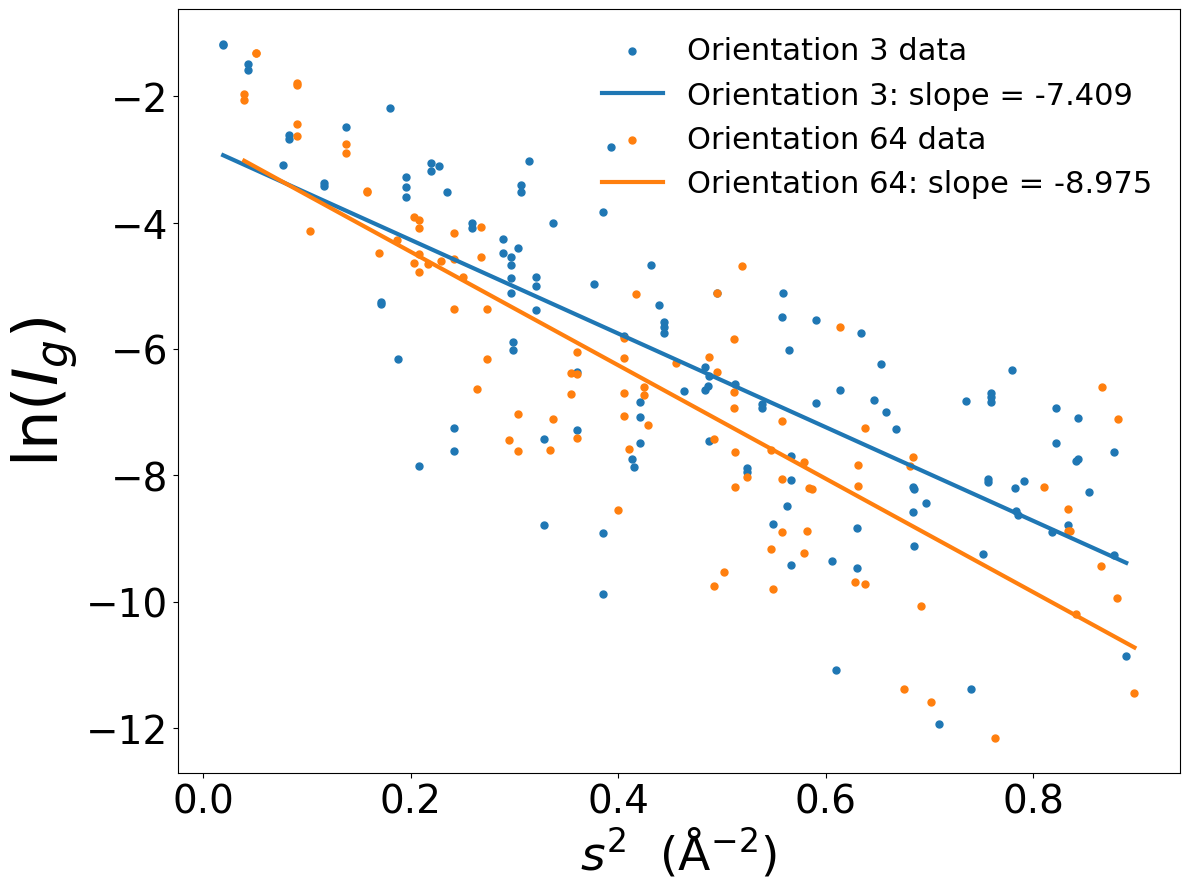

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- Loop over orientations in merged_total ---
orientations = sorted(merged_total["orientation"].unique())

plt.figure(figsize=(12, 9))

for ori in orientations:
    if (ori == 3 or ori == 64): 
        df_fit = merged_total[merged_total["orientation"] == ori].copy()
        df_fit = df_fit.dropna(subset=["_refln_intensity_meas", "G-vector Length"])
        df_fit = df_fit[df_fit["_refln_intensity_meas"] > 0]
        if df_fit.empty:
            continue

        x = (df_fit["G-vector Length"] / 2.0) ** 2
        y = np.log(df_fit["_refln_intensity_meas"])

        slope, intercept, r_value, _, _ = linregress(x, y)
        x_fit = np.linspace(x.min(), x.max(), 200)
        y_fit = intercept + slope * x_fit

        plt.scatter(x, y, s=25, label=f"Orientation {ori} data")
        plt.plot(
            x_fit,
            y_fit,
            linewidth=3.0,
            label=fr"Orientation {ori}: slope = {slope:.3f}"
        )

plt.xlabel(r"$s^2$  ($\mathrm{\AA}^{-2}$)", fontsize=34)
plt.ylabel(r"$\ln(I_g)$", fontsize=45)
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=22, loc="best", frameon=False)
plt.tight_layout()
plt.show()
